In [157]:
!pip install dmba

In [158]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier #if your dependent variable is binary
from sklearn.tree import DecisionTreeRegressor  #if your dependent variable is numerical, like Sales
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

import dmba
from dmba import plotDecisionTree, classificationSummary, regressionSummary

In [159]:
# Read the eBayAuctions.csv file and store the resulting table (DataFrame) in ebay_df.
ebay_df = pd.read_csv('eBayAuctions.csv')

# Show the first 5 rows
ebay_df.head()

,SellerRating,Duration,ClosePrice,OpenPrice,Competitive,EndDay,Currency,Category,Category.Art.Collectibles,Category.Books,Category.Clothing.Toys,Category.Coins.Stamps,Category.Computer.Electronics,Category.EverythingElse,Category.Health.Beauty,Category.Home.Garden,Category.Jewelry,Category.Music.Movie.Game,Currency.nonUS,EndDay.Weekend
0,3249,5,0.01,0.01,0,Week,US,Music/Movie/Game,0,0,0,0,0,0,0,0,0,1,0,0
1,3249,5,0.01,0.01,0,Week,US,Music/Movie/Game,0,0,0,0,0,0,0,0,0,1,0,0
2,3249,5,0.01,0.01,0,Week,US,Music/Movie/Game,0,0,0,0,0,0,0,0,0,1,0,0
3,3249,5,0.01,0.01,0,Week,US,Music/Movie/Game,0,0,0,0,0,0,0,0,0,1,0,0
4,3249,5,0.01,0.01,0,Week,US,Music/Movie/Game,0,0,0,0,0,0,0,0,0,1,0,0


In [160]:
# Show data type of each variable
ebay_df.dtypes

,0
SellerRating,int64
Duration,int64
ClosePrice,float64
OpenPrice,float64
Competitive,int64
EndDay,object
Currency,object
Category,object
Category.Art.Collectibles,int64
Category.Books,int64


In [161]:
# use to find if data has NaN, Na, or Space
ebay_df.isnull().any().any()

np.False_

In [162]:
# Convert current type into a pandas categorical variable and a numeric category code (for example, 0, 1, 2)..
columns = ['EndDay', 'Currency', 'Category']

for col in columns:
    ebay_df[col] = ebay_df[col].astype(pd.CategoricalDtype())
    ebay_df[col] = ebay_df[col].cat.codes

In [163]:
# Select Competitive as the dependent/outcome variable that we want the model to predict.
y = ebay_df['Competitive']

# to avoid multicollinearity, as 'Category' itself has been converted to numerical codes.
columns_to_drop = ['Competitive', 'Category.Art.Collectibles', 'Category.Books',
    'Category.Clothing.Toys', 'Category.Coins.Stamps', 'Category.Computer.Electronics',
    'Category.EverythingElse', 'Category.Health.Beauty', 'Category.Home.Garden',
    'Category.Jewelry', 'Category.Music.Movie.Game']

# Create X
X = ebay_df.drop(columns=columns_to_drop)

# Split X and Y into training data (70%) and testing data (30%).
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=42)

In [164]:
# Creates a decision-tree classifier and fixes the random seed for reproducible results.
classTree = DecisionTreeClassifier(random_state=0, max_depth=2)
# Trains the decision tree using the training data.
classTree.fit(train_X, train_y)

DecisionTreeClassifier(max_depth=2, random_state=0)

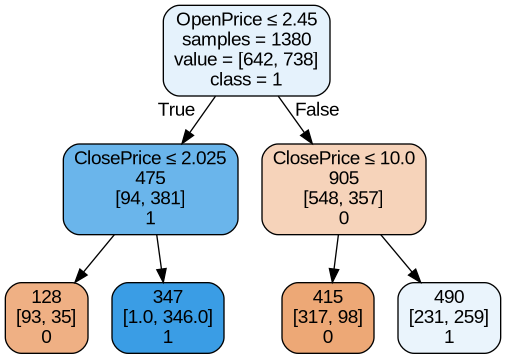

In [165]:
# Plots the trained decision tree using explicit feature names from the training set and the model's class labels.
plotDecisionTree(classTree, feature_names=train_X.columns, class_names=classTree.classes_)

In [166]:
# Evaluates the full decision tree on the training data by comparing actual and predicted classes.
classificationSummary(train_y, classTree.predict(train_X))

Confusion Matrix (Accuracy 0.7355)

       Prediction
Actual   0   1
     0 410 232
     1 133 605


In [167]:
# Evaluates the full decision tree on the test data by comparing actual and predicted classes.
classificationSummary(test_y, classTree.predict(test_X))

Confusion Matrix (Accuracy 0.7297)

       Prediction
Actual   0   1
     0 158 106
     1  54 274


### Random Forest

In [168]:
# Creates a random-forest classifier containing 500 decision trees and fixes the random seed.
# random_state should always be 1 to give you the same results
rf = RandomForestClassifier(n_estimators=500, random_state=1)
# Trains the random-forest classifier on the training data.
rf.fit(train_X, train_y)

RandomForestClassifier(n_estimators=500, random_state=1)

In [169]:
# Evaluates the random forest on the training data by comparing actual and predicted classes.
classificationSummary(train_y, rf.predict(train_X))

Confusion Matrix (Accuracy 0.9935)

       Prediction
Actual   0   1
     0 642   0
     1   9 729


In [170]:
# Evaluates the random forest on the test data by comparing actual and predicted classes.
classificationSummary(test_y, rf.predict(test_X))

Confusion Matrix (Accuracy 0.8936)

       Prediction
Actual   0   1
     0 240  24
     1  39 289
